# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape)

(30000, 44)


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This queue combines two things already built and validated in earlier notebooks: the
`stale_ctr_gap` rule score from `w04_baseline_score.ipynb` (which page, how urgent) and the
cluster archetype from `w05_model.ipynb` (what kind of page it is, which sets the default
action). Recomputing both here from the raw CSV keeps this notebook self-contained and makes
sure the queue this playbook exports matches the numbers those notebooks already reported.

In [2]:
tier_order = ["top_3", "page_1", "striking", "page_3_5", "deep"]

# same stale_ctr_gap rule as w04_baseline_score.ipynb
expected_ctr = (
    df[(df["impressions_90d"] >= 500) & (df["position_tier"].isin(tier_order))]
    .groupby("position_tier")["ctr"]
    .median()
)
df["expected_ctr"] = df["position_tier"].map(expected_ctr)
df["ctr_gap"] = (df["expected_ctr"] - df["ctr"]).clip(lower=0)

stale = (df["days_since_last_update"] >= 90).astype(int)
is_visible = (df["impressions_90d"] >= 500).astype(int)
has_position = df["position_tier"].isin(tier_order).astype(int)

df["score"] = stale * is_visible * has_position * df["ctr_gap"] * df["impressions_90d"]
df["reason_code"] = "stale_ctr_gap"

print("flagged (score > 0):", (df["score"] > 0).sum(), "of", len(df))

flagged (score > 0): 3227 of 30000


In [3]:
# same k=2 K-Means archetype from w05_model.ipynb, fit on the full 30k rows this time
# (w05 fit on an 80% train split; here we're scoring every page for the playbook export)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# is_declining_label is for naming the archetypes after the fact, never a clustering input --
# trend_direction / trend_pct never enter the feature list below.
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

NUMERIC_FEATURES = [
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct", "search_volume", "competition", "cpc",
    "word_count", "char_count",
]
CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent", "age_tier",
    "freshness_tier", "word_count_tier", "impression_tier", "position_tier",
]

def build_features(frame):
    X = frame[NUMERIC_FEATURES].copy()
    for col in ["search_volume", "competition", "cpc", "word_count", "char_count"]:
        X[f"has_{col}"] = X[col].notna().astype(int)
    X = X.fillna(0)
    cats = pd.get_dummies(frame[CATEGORICAL_FEATURES].fillna("unknown"), prefix=CATEGORICAL_FEATURES)
    return pd.concat([X, cats], axis=1)

X = build_features(df)
X_scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled)
df["cluster"] = km.labels_

cluster_decline = df.groupby("cluster")["is_declining_label"].mean()
cluster_size = df["cluster"].value_counts(normalize=True).sort_index()
print(cluster_decline)
print(cluster_size)

cluster
0    0.294985
1    0.563290
Name: is_declining_label, dtype: float64
cluster
0    0.0791
1    0.9209
Name: proportion, dtype: float64


In [4]:
# archetype -> action mapping, named from the cluster profiles in w05_model.ipynb.
# Name by decline rate rather than a hardcoded label id, since KMeans label numbering
# is arbitrary and can flip between fits.
higher_decline_cluster = cluster_decline.idxmax()
ARCHETYPE_NAMES = {
    higher_decline_cluster: "high_traffic_underperformer",
    1 - higher_decline_cluster: "low_volume_steady",
}
ARCHETYPE_ACTIONS = {
    "high_traffic_underperformer": "improve",   # big audience, worse position/ctr -> worth the review time
    "low_volume_steady": "monitor",             # small audience, already doing fine -> leave it, just watch
}

df["archetype"] = df["cluster"].map(ARCHETYPE_NAMES)
df["archetype_action"] = df["archetype"].map(ARCHETYPE_ACTIONS)

# final action: the urgency queue (score > 0) always wins when a page is flagged; otherwise
# fall back to the archetype's default action, so every page gets *some* action label
df["action_label"] = np.where(df["score"] > 0, "review_for_refresh", df["archetype_action"])

queue = df.sort_values("score", ascending=False)[
    ["content_id", "client_id", "score", "reason_code", "archetype", "action_label",
     "impressions_90d", "days_since_last_update", "position_tier", "ctr", "expected_ctr", "ctr_gap"]
]
queue.head(10)

,content_id,client_id,score,reason_code,archetype,action_label,impressions_90d,days_since_last_update,position_tier,ctr,expected_ctr,ctr_gap
3394,content_36ff89c8214e,client_19581e27de,56068.43,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,295097,104,page_1,0.05,0.24,0.19
6653,content_5fe46e04994d,client_4e07408562,51771.50,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,517715,104,page_1,0.14,0.24,0.10
7445,content_c8e9d6ab9013,client_19581e27de,50082.72,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,208678,104,page_1,0.00,0.24,0.24
3070,content_91652435f57a,client_19581e27de,28726.20,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,159590,104,page_1,0.06,0.24,0.18
9193,content_c1fe78bc4e37,client_19581e27de,28151.55,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,134055,104,page_1,0.03,0.24,0.21
26474,content_a7427266c305,client_19581e27de,26144.43,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,201111,104,page_1,0.11,0.24,0.13
4708,content_b115f7c74779,client_19581e27de,25928.49,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,123469,104,page_1,0.03,0.24,0.21
5621,content_97a86caf3a3d,client_19581e27de,25103.90,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,147670,104,page_1,0.07,0.24,0.17
26531,content_cb112fce36be,client_19581e27de,24792.80,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,309910,104,page_1,0.16,0.24,0.08
3331,content_4a6607efcb46,client_6208ef0f77,24332.92,stale_ctr_gap,high_traffic_underperformer,review_for_refresh,128068,104,top_3,0.01,0.20,0.19


**The decay/refresh insight, from the signal checks in `w04_baseline_score.ipynb`:** ctr
drops almost the whole way down the position tiers (page_1 0.24 → striking 0.17 →
page_3_5 0.09 → deep 0.00), and median position gets worse the staler a page is (10.6 days
0-30 → 18.6 days 181+). Both hold in this data. That's the mechanism behind the queue above:
pages sitting on page 1 or better that haven't been touched in 90+ days and are underperforming
their own tier's ctr are the ones with real upside left — not pages already buried on page 5,
where a refresh probably won't move the needle.

Top of the queue skews toward the `high_traffic_underperformer` archetype, which matches how the
score is built: it multiplies the ctr gap by `impressions_90d`, so a big page with a modest gap
outranks a tiny page with a huge one. That's a deliberate choice — it points reviewers at
the pages where fixing the gap recovers the most clicks — but it also means the queue is
biased toward finding problems on pages that already get traffic, not toward pages that could be
getting traffic and aren't.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use.** A content team lead or SEO reviewer scans the top of this queue once a
review cycle (weekly or biweekly) to decide which pages to look at first, given limited review
time. It's a triage tool: it tells you where to look, not what to change on the page.

**Limits, from what the earlier notebooks already found:**

- This is one trailing-90-day snapshot, not a trend. The score can't tell a page that's been
  declining for months from one that just had a single bad week; there is no before/after here,
  only a comparison against peers.
- Client concentration is real. In `w04_baseline_score.ipynb`, 8 of the top 10 rows by score
  belonged to one client and shared the exact same `days_since_last_update`, which looks like one
  batch content-update event, not eight independent problems. Anyone working this queue should
  check for that pattern before treating a run of same-client hits as eight separate wins.
- The model comparison isn't settled. `w06_validation_audit.ipynb` found that the cluster-based
  ranking beat the baseline on a plain random split, but the gap (and the base rate itself)
  shifted once the split was grouped by client. The archetype tags here are useful for sorting
  pages into rough buckets; they aren't validated well enough yet to be the sole reason to act
  on a page.
- No causal claim. Nothing here says a refresh will fix these pages -- the data is
  cross-sectional, and refreshing is a decision someone makes, not something this notebook
  observed happening. The honest framing is: these pages look worth reviewing first, because
  they sit on real position with an unusually large gap to their own tier's typical CTR.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any page from this queue, a human should check:**

- Is the `ctr_gap` a tracking artifact? A page at close-to-zero ctr on high impressions (several
  appear in the w04 top-10) is as likely to be a broken GSC tag or a canonical/URL split as an
  actual content problem -- check Search Console for the raw click numbers before rewriting
  anything.
- Is this one client-wide event, not several separate problems? Group the day's queue by
  `client_id` and `days_since_last_update` first; a cluster of same-day, same-client hits is one
  decision, not several.
- Does the query intent behind the page make a title/metadata fix pointless? A page can have a
  real ctr gap because its top queries are brand or navigational, where no rewrite moves the
  number.
- Is a SERP feature (featured snippet, answer box) sitting on top of the query, eating clicks
  structurally? That also shows up as a ctr gap and no content change fixes it.

**No-go list -- never automate:**

- Auto-publishing a rewritten title, meta description, or body copy from this score alone.
- Auto-deprioritizing or removing a page because it scored 0 (no impressions above the 500
  threshold does not mean the page has no value -- it may be seasonal, new, or intentionally
  low-traffic).
- Treating the archetype label as a health verdict on its own client-facing report; it's an
  internal sorting aid, not a validated score to show a client.
- Batch-editing every page under one client in a single pass because they share a queue
  position -- see the concentration check above.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Cost/value framing.** Review time is the scarce resource, not compute -- recomputing
this queue is cheap; a person reading each flagged page is not. The queue is ordered so the
pages worth the most reviewer time (biggest ctr gap times biggest audience) come first, on the
assumption a fixed reviewer budget should go to the highest-upside pages, not the most numerous.

**Re-run the queue** on the normal reporting cadence (matching whatever window
`impressions_90d` / `days_since_last_update` already use, e.g. monthly), so staleness gates and
CTR gaps reflect the current snapshot rather than a stale one.

**Retrain / recheck triggers -- signs the queue needs attention, not just a refresh:**

- The flagged count (`score > 0`) jumps or collapses by a large margin between runs without a
  matching change in traffic -- check for a pipeline or data issue before trusting the new
  queue.
- The overall decline base rate moves a lot between runs (it shifted from 0.545 to 0.511 just by
  changing the split in `w06_validation_audit.ipynb`, a reminder that this number is sensitive to
  which pages/clients are in view).
- A new client gets onboarded -- the archetype clusters were fit on this dataset's current 32
  clients, so a very different new client's pages may not sort cleanly into either archetype.
- Someone actually acts on a page and later checks whether it moved -- that's the real test of
  whether the score means anything, and it hasn't been run yet. Until then, treat archetype
  labels as a sorting aid, not a verdict.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [5]:
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("wrote", len(queue), "rows to work/outputs/action_playbook_queue.csv")

wrote 30000 rows to work/outputs/action_playbook_queue.csv


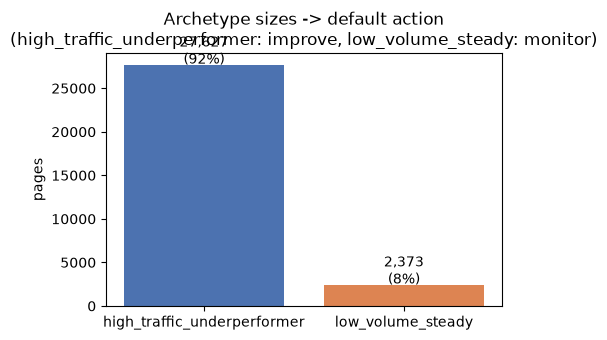

saved work/figures/archetype_sizes.png


In [6]:
# one figure for the paper: archetype size vs its default action, so the mapping is visible
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["archetype"].value_counts()
ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(df):.0%})", ha="center")
ax.set_ylabel("pages")
ax.set_title("Archetype sizes -> default action\n(high_traffic_underperformer: improve, low_volume_steady: monitor)")
plt.tight_layout()
plt.savefig("work/figures/archetype_sizes.png", dpi=120)
plt.show()
print("saved work/figures/archetype_sizes.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.